In [2]:
## Build A Basic Chatbot with LangGraph

In [1]:
%pip install langgraph langchain langsmith

  Using cached langgraph-1.2.4-py3-none-any.whl.metadata (8.0 kB)
  Using cached langsmith-0.8.9-py3-none-any.whl.metadata (15 kB)
  Using cached langchain_core-1.4.1-py3-none-any.whl.metadata (4.5 kB)
  Using cached langgraph_checkpoint-4.1.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
Using cached langgraph-1.2.4-py3-none-any.whl (245 kB)
   ---------------------------------------- 0.0/125.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/125.3 kB ? eta -:--:--
   --- ------------------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [25]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages'function
    # in the annotation defined how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [27]:
graph_builder

In [5]:
%pip install python-dotenv

  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [39]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
%pip install langchain-groq

  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/137.5 kB ? eta -:--:--
   ----------------- ---------------------- 61.4/137.5 kB 3.2 MB/s eta 0:00:01
   -------------------------- ------------- 92.2/137.5 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 137.5/137.5 kB 1.2 MB/s eta 0:00:00
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [28]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")

In [29]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000295D1E998D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000295D1E9A990>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [12]:
#### llm=initialize_chat_model("groq", model="llama3-8b-8192")

In [30]:
def chatbot(state:State) -> State:
    return {"messages":[llm.invoke(state["messages"])]}

In [31]:
graph_builder.add_node("llmchatbot1", chatbot)

graph_builder.add_edge(START, "llmchatbot1")
graph_builder.add_edge("llmchatbot1", END)

graph=graph_builder.compile()

In [15]:
%pip install ipython

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


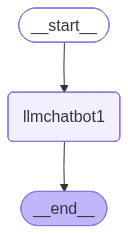

In [32]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred: {e}")

In [34]:
response = graph.invoke({"messages":"Hi"})

In [36]:
response['messages'][-1].content

'How can I assist you today?'

In [37]:
for event in graph.stream({"messages":"Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm functioning properly. How can I assist you today?


In [38]:
%pip install langchain-tavily

  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp311-cp311-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
     ---------------------------------------- 0.0/97.2 kB ? eta -:--:--
     --------------------------------- ------ 81.9/97.2 kB 2.3 MB/s eta 0:00:01
     ---------------------------------------- 97.2/97.2 kB 1.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/479.3 kB ? eta -:--:--
   ----- ---------------------------------- 71.7/479.3 kB 2.0 MB/s eta 0:00:01
   ----------- ---------------------------- 143.4/479.3 kB 2.1 MB/s eta 0:00:01
   ------------------- -------------------- 235.5/479.3 kB 1.8 MB/s eta 0:00:01
   ---------------------------- ----------- 337.9/479.3 kB 2.1 MB/s eta 0:00:01
   ------------------------------------- -- 450.6/479.3 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 479.3/479.3 kB 2.0 MB/s eta 0:00:00
Us


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [40]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the navigat

In [51]:
## Custom Function
def multiply(a:int, b:int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [42]:
tools=[tool,multiply]

In [43]:
llm_with_tool=llm.bind_tools(tools)

In [44]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000295D1E998D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000295D1E9A990>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

In [45]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

## compile the graph
graph=builder.compile()


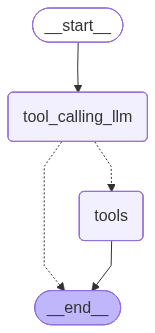

In [46]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:
response = graph.invoke({"messages":[{"role":"user","content":"What is the recent AI news?"}]})

In [49]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/tokenmaxxing-maxes-out-37103747", "title": "‘Tokenmaxxing’ AI Use Is Now Under Scrutiny | Technology for May 31 - WSJ", "score": 0.6504012, "published_date": "Sun, 31 May 2026 13:30:00 GMT", "content": "Investors and corporate leaders see this as a natural shift from unbridled experimentation to something a little more measured, rather than some harbinger of doom for the AI race. But how it shakes up the coming IPOs of three potentially trillion-dollar AI companies—SpaceX, OpenAI and Anthropic—is anyone’s guess.\\n\\n_—Bradley is the deputy tech bureau chief in San Francisco._\\n\\n  \\n\\n### The Latest From Our Columnists\\n\\nImage 2: Illustration of the Greek letter delta over a background of mathematical equations.\\n\\nEmil Lendof/WSJ\\n\\n#### Ben Cohen: A Famous Math Problem Stumped Humans for 80 Years. AI Just Cracked It.\\n\\n“If you are a math

In [50]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (byfakny4m)
 Call ID: byfakny4m
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/tokenmaxxing-maxes-out-37103747", "title": "‘Tokenmaxxing’ AI Use Is Now Under Scrutiny | Technology for May 31 - WSJ", "score": 0.6504012, "published_date": "Sun, 31 May 2026 13:30:00 GMT", "content": "Investors and corporate leaders see this as a natural shift from unbridled experimentation to something a little more measured, rather than some harbinger of doom for the AI race. But how it shakes up the coming I

In [52]:
## ReAct Architecture

In [53]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
# React architecture allows the LLM to call tools multiple times in a single conversation, so we add an edge from tools back to the tool_calling_llm node, allowing the LLM to call another tool after receiving the results from the previous tool call.
builder.add_edge("tools", "tool_calling_llm")

## compile the graph
graph=builder.compile()


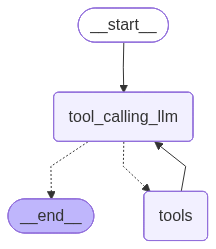

In [54]:
display(Image(graph.get_graph().draw_mermaid_png()))